<a href="https://colab.research.google.com/github/AlbertoAmayaSoria/Trabajos-Universidad/blob/main/Tarea1_AnalisisAlgoritmos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [215]:
import os
os.cpu_count()

8

In [216]:
import timeit
import random
import time
import matplotlib.pyplot as plt
import numpy as np
import pandas

#Inserion-sort

In [217]:
def inserton_sort(arr):
    n = len(arr)

    for i in range(1, n):
        key = arr[i]

        j = i - 1

        while j >= 0 and arr[j] > key:
            arr[j + 1] = arr[j]
            j -= 1

        arr[j + 1] = key

# Selection_sort

In [218]:
def selection_sort(arr):
    n = len(arr)

    for i in range(n - 1):

        min_index = i

        for j in range(i + 1, n):
            if arr[j] < arr[min_index]:
                min_index = j

        arr[i], arr[min_index] = arr[min_index], arr[i]

# Merge sort

In [219]:
def merge_sort(arr):

    if len(arr) <= 1:
        return arr

    mid = len(arr) // 2

    left = merge_sort(arr[:mid])
    right = merge_sort(arr[mid:])

    return merge(left, right)

In [220]:
def merge(left, right):

    resultado = []
    i = 0
    j = 0

    while i < len(left) and j < len(right):

        if left[i] <= right[j]:
            resultado.append(left[i])
            i += 1
        else:
            resultado.append(right[j])
            j += 1

    resultado.extend(left[i:])
    resultado.extend(right[j:])

    return resultado

In [221]:
def generar_listas(n):
    listaO = list(range(1, n+1))
    listaS = list(range(n, 0, -1))
    listaR = listaO.copy()
    random.shuffle(listaR)

    return listaO, listaS, listaR

In [222]:
def tiempo_promedio(lista, algoritmo):

    total = 0

    for _ in range(10):

        copia = lista.copy()

        if algoritmo == "1":
          inicio = time.perf_counter()
          inserton_sort(copia)
          fin = time.perf_counter()

        elif algoritmo == "2":
          inicio = time.perf_counter()
          selection_sort(copia)
          fin = time.perf

        else:
          inicio = time.perf_counter()
          merge_sort(copia)
          fin = time.perf_counter()

        total += (fin - inicio)

    return total / 10

In [223]:
dfIS = pandas.DataFrame(columns=["Algoritmo", "caso", "Tamaño de la lista", "Tiempo"])


# Inserion sort

In [224]:
mejor_caso = []
peor_caso = []
caso_promedio = []

In [225]:
n_vals = [100000, 200000, 300000, 400000, 500000, 600000, 700000, 800000, 900000, 1000000]

In [226]:
for i in n_vals:
  listaO, listaS, listaR = generar_listas(i)

  t1 = tiempo_promedio(listaO, 1)
  print(f"El timepo promedio de una lista ordenada con {i} elementos es: {t1}")
  #df.loc[len(df)] = ['inserion sort', 'mejor', i, t1]
  dfIS.loc[len(dfIS)] = {
    "Algoritmo": "inserion sort",
    "caso": "mejor",
    "Tamaño de la lista": i,
    "Tiempo": t1
  }
  t2 = tiempo_promedio(listaS, 1)
  #df.loc[len(df)] = ['inserion sort', 'mejor', i, t2]
  dfIS.loc[len(dfIS)] = {
    "Algoritmo": "inserion sort",
    "caso": "peor",
    "Tamaño de la lista": i,
    "Tiempo": t2
  }
  print(f"El timepo promedio de una lista invertida con {i} elementos es: {t2}")
  t3 = tiempo_promedio(listaR, 1)
  #df.loc[len(df)] = ['inserion sort', 'mejor', i, t3]
  dfIS.loc[len(dfIS)] = {
    "Algoritmo": "inserion sort",
    "caso": "promedio",
    "Tamaño de la lista": i,
    "Tiempo": t3
  }
  print(f"El timepo promedio de una lista revuelta con {i} elementos es: {t3}")
  mejor_caso.append(t1)
  caso_promedio.append(t2)
  peor_caso.append(t3)


El timepo promedio de una lista ordenada con 100000 elementos es: 0.15458665030018892
El timepo promedio de una lista invertida con 100000 elementos es: 0.1543577404005191
El timepo promedio de una lista revuelta con 100000 elementos es: 0.2553273015000741
El timepo promedio de una lista ordenada con 200000 elementos es: 0.3310848118995636
El timepo promedio de una lista invertida con 200000 elementos es: 0.3243029826997372
El timepo promedio de una lista revuelta con 200000 elementos es: 0.5791545504996976
El timepo promedio de una lista ordenada con 300000 elementos es: 0.5267369621999023
El timepo promedio de una lista invertida con 300000 elementos es: 0.5300139329998274
El timepo promedio de una lista revuelta con 300000 elementos es: 0.9269630758002677
El timepo promedio de una lista ordenada con 400000 elementos es: 0.7179545415001485
El timepo promedio de una lista invertida con 400000 elementos es: 0.7364245763003054
El timepo promedio de una lista revuelta con 400000 elemento

In [227]:
dfIS

,Algoritmo,caso,Tamaño de la lista,Tiempo
0,inserion sort,mejor,100000,0.154587
1,inserion sort,peor,100000,0.154358
2,inserion sort,promedio,100000,0.255327
3,inserion sort,mejor,200000,0.331085
4,inserion sort,peor,200000,0.324303
5,inserion sort,promedio,200000,0.579155
6,inserion sort,mejor,300000,0.526737
7,inserion sort,peor,300000,0.530014
8,inserion sort,promedio,300000,0.926963
9,inserion sort,mejor,400000,0.717955


# Selection sort

In [228]:
dfSS = pandas.DataFrame(columns=["Algoritmo", "caso", "Tamaño de la lista", "Tiempo"])

In [229]:
mejor_caso_ss = []
peor_caso_ss = []
caso_promedio_ss = []

In [230]:
for i in n_vals:
  listaO, listaS, listaR = generar_listas(i)

  t1 = tiempo_promedio(listaO, 2)
  print(f"El timepo promedio de una lista ordenada con {i} elementos es: {t1}")
  dfSS.loc[len(dfSS)] = {
    "Algoritmo": "selection sort",
    "caso": "mejor",
    "Tamaño de la lista": i,
    "Tiempo": t1
  }

  t2 = tiempo_promedio(listaS, 2)
  print(f"El timepo promedio de una lista invertida con {i} elementos es: {t2}")
  dfSS.loc[len(dfSS)] = {
    "Algoritmo": "selection sort",
    "caso": "peor",
    "Tamaño de la lista": i,
    "Tiempo": t2
  }

  t3 = tiempo_promedio(listaR, 2)
  print(f"El timepo promedio de una lista revuelta con {i} elementos es: {t3}")
  dfSS.loc[len(dfSS)] = {
    "Algoritmo": "selection sort",
    "caso": "promedio",
    "Tamaño de la lista": i,
    "Tiempo": t3
  }
  mejor_caso_ss.append(t1)
  caso_promedio_ss.append(t2)
  peor_caso_ss.append(t3)


El timepo promedio de una lista ordenada con 100000 elementos es: 0.16301963570022054
El timepo promedio de una lista invertida con 100000 elementos es: 0.16988838529996428
El timepo promedio de una lista revuelta con 100000 elementos es: 0.26893933060000563
El timepo promedio de una lista ordenada con 200000 elementos es: 0.3460130096995272
El timepo promedio de una lista invertida con 200000 elementos es: 0.3510773796000649
El timepo promedio de una lista revuelta con 200000 elementos es: 0.5819653417000155
El timepo promedio de una lista ordenada con 300000 elementos es: 0.5371178081002654
El timepo promedio de una lista invertida con 300000 elementos es: 0.5525294438997662
El timepo promedio de una lista revuelta con 300000 elementos es: 0.9985947156001203
El timepo promedio de una lista ordenada con 400000 elementos es: 0.7760945453002932
El timepo promedio de una lista invertida con 400000 elementos es: 0.7642925241003468
El timepo promedio de una lista revuelta con 400000 elemen

In [231]:
dfSS

,Algoritmo,caso,Tamaño de la lista,Tiempo
0,selection sort,mejor,100000,0.163020
1,selection sort,peor,100000,0.169888
2,selection sort,promedio,100000,0.268939
3,selection sort,mejor,200000,0.346013
4,selection sort,peor,200000,0.351077
5,selection sort,promedio,200000,0.581965
6,selection sort,mejor,300000,0.537118
7,selection sort,peor,300000,0.552529
8,selection sort,promedio,300000,0.998595
9,selection sort,mejor,400000,0.776095


# Merge sort

In [232]:
dfMS = pandas.DataFrame(columns=["Algoritmo", "caso", "Tamaño de la lista", "Tiempo"])

In [233]:
mejor_caso_ms = []
peor_caso_ms = []
caso_promedio_ms = []

In [234]:
for i in n_vals:
  listaO, listaS, listaR = generar_listas(i)

  t1 = tiempo_promedio(listaO, 3)
  print(f"El timepo promedio de una lista ordenada con {i} elementos es: {t1}")
  dfMS.loc[len(dfMS)] = {
    "Algoritmo": "merge sort",
    "caso": "mejor",
    "Tamaño de la lista": i,
    "Tiempo": t1
  }

  t2 = tiempo_promedio(listaS, 3)
  print(f"El timepo promedio de una lista invertida con {i} elementos es: {t2}")
  dfMS.loc[len(dfMS)] = {
    "Algoritmo": "merge sort",
    "caso": "peor",
    "Tamaño de la lista": i,
    "Tiempo": t2
  }

  t3 = tiempo_promedio(listaR, 3)
  print(f"El timepo promedio de una lista revuelta con {i} elementos es: {t3}")
  dfMS.loc[len(dfMS)] = {
    "Algoritmo": "merge sort",
    "caso": "promedio",
    "Tamaño de la lista": i,
    "Tiempo": t3
  }

  mejor_caso_ms.append(t1)
  caso_promedio_ms.append(t2)
  peor_caso_ms.append(t3)

El timepo promedio de una lista ordenada con 100000 elementos es: 0.16584148310030286
El timepo promedio de una lista invertida con 100000 elementos es: 0.16904680320003534
El timepo promedio de una lista revuelta con 100000 elementos es: 0.26627450739979397
El timepo promedio de una lista ordenada con 200000 elementos es: 0.34662662189948606
El timepo promedio de una lista invertida con 200000 elementos es: 0.3667850133006141
El timepo promedio de una lista revuelta con 200000 elementos es: 0.5962995647001662
El timepo promedio de una lista ordenada con 300000 elementos es: 0.5418861701993591
El timepo promedio de una lista invertida con 300000 elementos es: 0.5828569246008556
El timepo promedio de una lista revuelta con 300000 elementos es: 1.023069510100686
El timepo promedio de una lista ordenada con 400000 elementos es: 0.7510526029989706
El timepo promedio de una lista invertida con 400000 elementos es: 0.7390555634003249
El timepo promedio de una lista revuelta con 400000 elemen

In [235]:
dfMS

,Algoritmo,caso,Tamaño de la lista,Tiempo
0,merge sort,mejor,100000,0.165841
1,merge sort,peor,100000,0.169047
2,merge sort,promedio,100000,0.266275
3,merge sort,mejor,200000,0.346627
4,merge sort,peor,200000,0.366785
5,merge sort,promedio,200000,0.596300
6,merge sort,mejor,300000,0.541886
7,merge sort,peor,300000,0.582857
8,merge sort,promedio,300000,1.023070
9,merge sort,mejor,400000,0.751053


## Ajuste lineal

In [236]:
def ajuste_lineal(x, y):

    n = len(x)

    sum_x = sum(x)
    sum_y = sum(y)

    sum_xy = sum(x[i]*y[i] for i in range(n))
    sum_x2 = sum(x[i]**2 for i in range(n))

    a = (n*sum_xy - sum_x*sum_y) / (n*sum_x2 - sum_x**2)
    b = (sum_y - a*sum_x) / n

    return a, b

# insertion sort

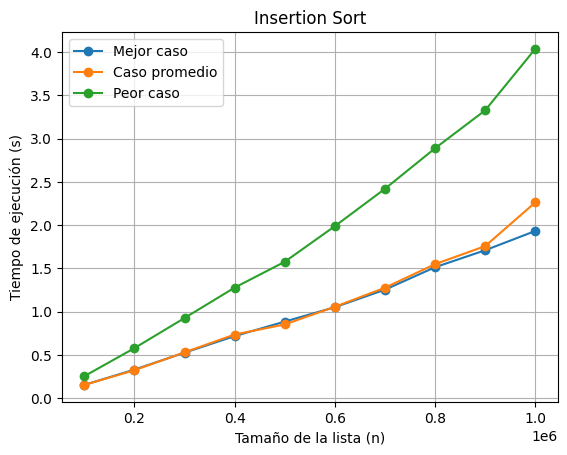

In [237]:
import matplotlib.pyplot as plt

# Truncate lists to match the length of n_vals
mejor_caso = mejor_caso[:len(n_vals)]
caso_promedio = caso_promedio[:len(n_vals)]
peor_caso = peor_caso[:len(n_vals)]

plt.plot(n_vals, mejor_caso, marker='o', label="Mejor caso")
plt.plot(n_vals, caso_promedio, marker='o', label="Caso promedio")
plt.plot(n_vals, peor_caso, marker='o', label="Peor caso")

plt.xlabel("Tamaño de la lista (n)")
plt.ylabel("Tiempo de ejecución (s)")
plt.title("Insertion Sort")

plt.legend()
plt.grid(True)

plt.show()

## Ajuste lineal

In [238]:
aMCIS, bMCIS = ajuste_lineal(n_vals, mejor_caso)
aCPIS, bCPIS = ajuste_lineal(n_vals, caso_promedio)
aPCIS, bPCIS = ajuste_lineal(n_vals, peor_caso)


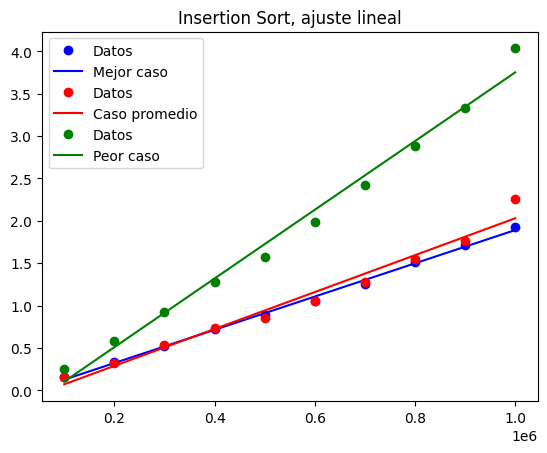

In [239]:
y_fitMC = [aMCIS*x + bMCIS for x in n_vals]
y_fitCP = [aCPIS*x + bCPIS for x in n_vals]
y_fitPC = [aPCIS*x + bPCIS for x in n_vals]

plt.plot(n_vals, mejor_caso, 'o', color='blue', label="Datos")
plt.plot(n_vals, y_fitMC, color='blue', label="Mejor caso")

plt.plot(n_vals, caso_promedio, 'o', color='red', label="Datos")
plt.plot(n_vals, y_fitCP, color='red', label="Caso promedio")

plt.plot(n_vals, peor_caso, 'o', color='green', label="Datos")
plt.plot(n_vals, y_fitPC, color='green', label="Peor caso")

plt.title("Insertion Sort, ajuste lineal")

plt.legend()
plt.show()

## Ajuste cuadratico

In [240]:
coef_MC = np.polyfit(n_vals, mejor_caso, 2)
coef_CP = np.polyfit(n_vals, caso_promedio, 2)
coef_PC = np.polyfit(n_vals, peor_caso, 2)

aMCIS, bMCIS, cMCIS = coef_MC
aCPIS, bCPIS, cCPIS = coef_CP
aPCIS, bPCIS, cPCIS = coef_PC

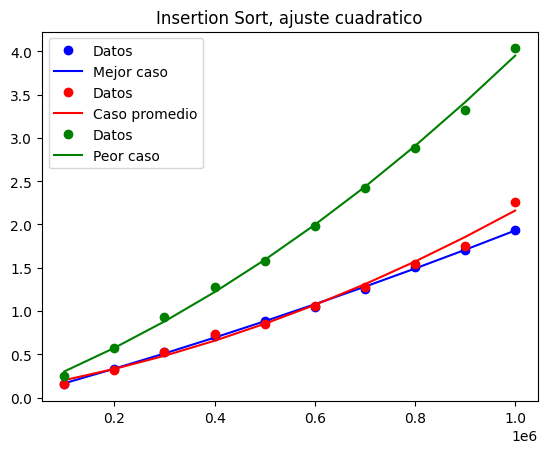

In [241]:
y_fitMC = [aMCIS*x**2 + bMCIS*x + cMCIS for x in n_vals]
y_fitCP = [aCPIS*x**2 + bCPIS*x + cCPIS for x in n_vals]
y_fitPC = [aPCIS*x**2 + bPCIS*x + cPCIS for x in n_vals]

plt.plot(n_vals, mejor_caso, 'o', color='blue', label="Datos")
plt.plot(n_vals, y_fitMC, color='blue', label="Mejor caso")

plt.plot(n_vals, caso_promedio, 'o', color='red', label="Datos")
plt.plot(n_vals, y_fitCP, color='red', label="Caso promedio")

plt.plot(n_vals, peor_caso, 'o', color='green', label="Datos")
plt.plot(n_vals, y_fitPC, color='green', label="Peor caso")

plt.title("Insertion Sort, ajuste cuadratico")

plt.legend()
plt.show()

# Selection sort

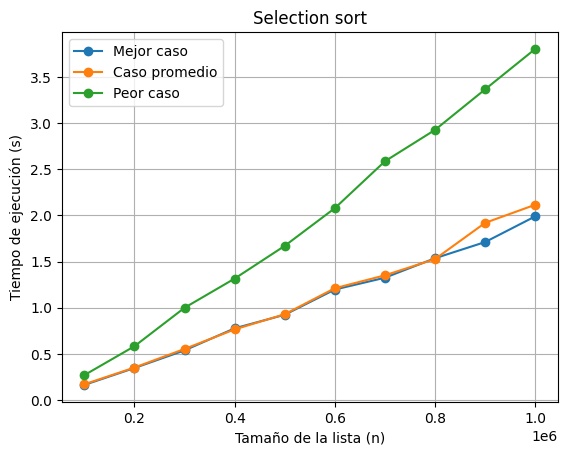

In [242]:
import matplotlib.pyplot as plt

plt.plot(n_vals, mejor_caso_ss, marker='o', label="Mejor caso")
plt.plot(n_vals, caso_promedio_ss, marker='o', label="Caso promedio")
plt.plot(n_vals, peor_caso_ss, marker='o', label="Peor caso")

plt.xlabel("Tamaño de la lista (n)")
plt.ylabel("Tiempo de ejecución (s)")
plt.title("Selection sort")

plt.legend()
plt.grid(True)

plt.show()

# Ajuste lineal

In [243]:
aMCSS, bMCSS = ajuste_lineal(n_vals, mejor_caso_ss)
aCPSS, bCPSS = ajuste_lineal(n_vals, caso_promedio_ss)
aPCSS, bPCSS = ajuste_lineal(n_vals, peor_caso_ss)

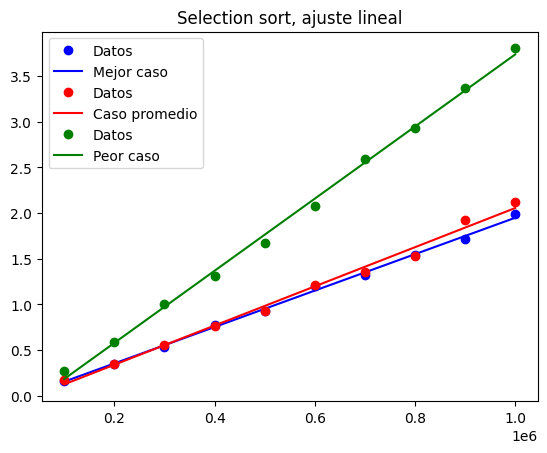

In [244]:
y_fitMCSS = [aMCSS*x + bMCSS for x in n_vals]
y_fitCPSS = [aCPSS*x + bCPSS for x in n_vals]
y_fitPCSS = [aPCSS*x + bPCSS for x in n_vals]

plt.plot(n_vals, mejor_caso_ss, 'o', color='blue', label="Datos")
plt.plot(n_vals, y_fitMCSS, color='blue', label="Mejor caso")

plt.plot(n_vals, caso_promedio_ss, 'o', color='red', label="Datos")
plt.plot(n_vals, y_fitCPSS, color='red', label="Caso promedio")

plt.plot(n_vals, peor_caso_ss, 'o', color='green', label="Datos")
plt.plot(n_vals, y_fitPCSS, color='green', label="Peor caso")

plt.title("Selection sort, ajuste lineal")

plt.legend()
plt.show()

## Ajuste cuadratico

In [245]:
coef_MCSS = np.polyfit(n_vals, mejor_caso_ss, 2)
coef_CPSS = np.polyfit(n_vals, caso_promedio_ss, 2)
coef_PCSS = np.polyfit(n_vals, peor_caso_ss, 2)

aMCSS, bMCSS, cMCSS = coef_MCSS
aCPSS, bCPSS, cCPSS = coef_CPSS
aPCSS, bPCSS, cPCSS = coef_PCSS

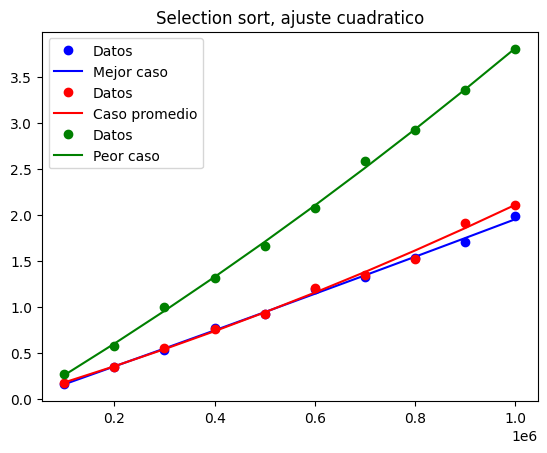

In [246]:
y_fitMCSS = [aMCSS*x**2 + bMCSS*x + cMCSS for x in n_vals]
y_fitCPSS = [aCPSS*x**2 + bCPSS*x + cCPSS for x in n_vals]
y_fitPCSS = [aPCSS*x**2 + bPCSS*x + cPCSS for x in n_vals]

plt.plot(n_vals, mejor_caso_ss, 'o', color='blue', label="Datos")
plt.plot(n_vals, y_fitMCSS, color='blue', label="Mejor caso")

plt.plot(n_vals, caso_promedio_ss, 'o', color='red', label="Datos")
plt.plot(n_vals, y_fitCPSS, color='red', label="Caso promedio")

plt.plot(n_vals, peor_caso_ss, 'o', color='green', label="Datos")
plt.plot(n_vals, y_fitPCSS, color='green', label="Peor caso")

plt.title("Selection sort, ajuste cuadratico")

plt.legend()
plt.show()

# Merged sort

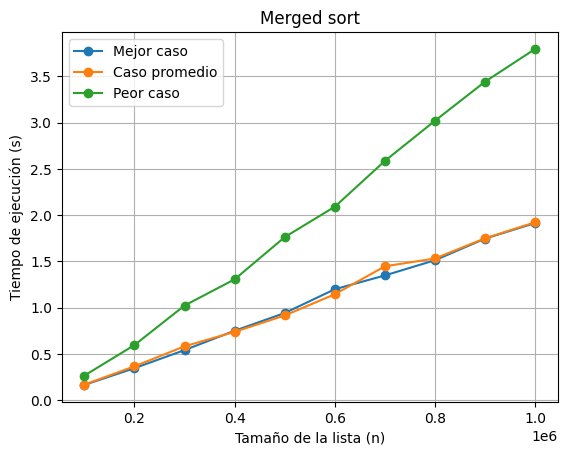

In [247]:
import matplotlib.pyplot as plt

plt.plot(n_vals, mejor_caso_ms, marker='o', label="Mejor caso")
plt.plot(n_vals, caso_promedio_ms, marker='o', label="Caso promedio")
plt.plot(n_vals, peor_caso_ms, marker='o', label="Peor caso")

plt.xlabel("Tamaño de la lista (n)")
plt.ylabel("Tiempo de ejecución (s)")
plt.title("Merged sort")

plt.legend()
plt.grid(True)

plt.show()

# Graficas de las funciones

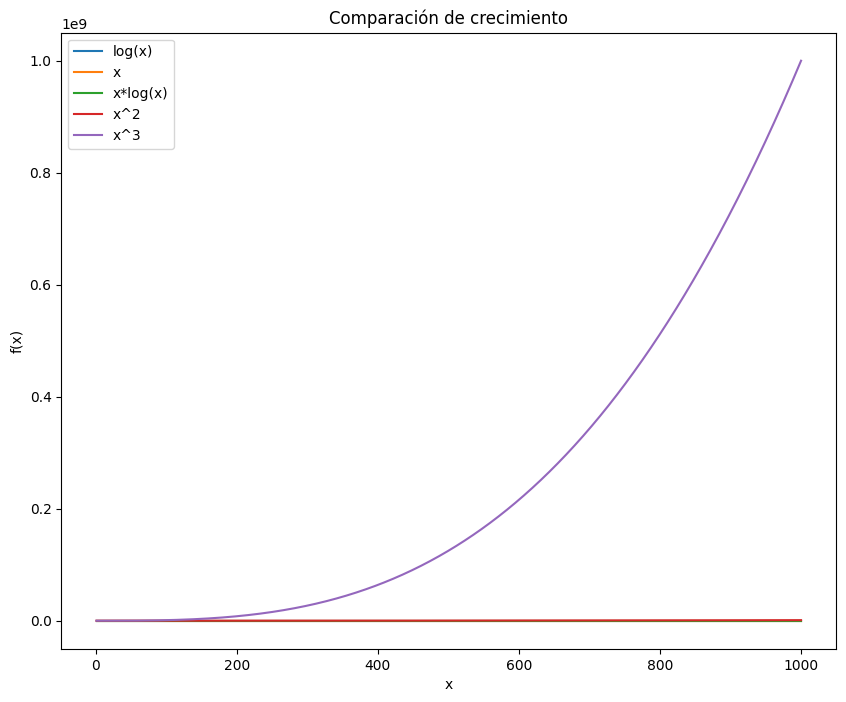

In [248]:
x = np.linspace(1, 1000, 1000)

y_log = np.log(x)
y_lineal = x
y_x_log = x * np.log(x)
y_xx = x**2
y_xxx = x**3

plt.figure(figsize=(10,8))

plt.plot(x, y_log, label="log(x)")
plt.plot(x, y_lineal, label="x")
plt.plot(x, y_x_log, label="x*log(x)")
plt.plot(x, y_xx, label="x^2")
plt.plot(x, y_xxx, label="x^3")

plt.xlabel("x")
plt.ylabel("f(x)")
plt.title("Comparación de crecimiento")

plt.legend()
plt.show()

# Crear las tablas con los tiempos calculados

In [249]:
df_completo = pd.concat([dfIS, dfMS, dfSS])
df_completo

,Algoritmo,caso,Tamaño de la lista,Tiempo
0,inserion sort,mejor,100000,0.154587
1,inserion sort,peor,100000,0.154358
2,inserion sort,promedio,100000,0.255327
3,inserion sort,mejor,200000,0.331085
4,inserion sort,peor,200000,0.324303
...,...,...,...,...
25,selection sort,peor,900000,1.918758
26,selection sort,promedio,900000,3.365086
27,selection sort,mejor,1000000,1.988953
28,selection sort,peor,1000000,2.114842


#Tiempos promedio por algoritmo

In [250]:
df_IS_MC = df_completo[(df_completo['Algoritmo'] == 'inserion sort') & (df_completo['caso'] == 'mejor')]
df_IS_MC

,Algoritmo,caso,Tamaño de la lista,Tiempo
0,inserion sort,mejor,100000,0.154587
3,inserion sort,mejor,200000,0.331085
6,inserion sort,mejor,300000,0.526737
9,inserion sort,mejor,400000,0.717955
12,inserion sort,mejor,500000,0.885818
15,inserion sort,mejor,600000,1.051773
18,inserion sort,mejor,700000,1.254131
21,inserion sort,mejor,800000,1.513473
24,inserion sort,mejor,900000,1.709362
27,inserion sort,mejor,1000000,1.931861


In [260]:
df_IS_PC = df_completo[(df_completo['Algoritmo'] == 'inserion sort') & (df_completo['caso'] == 'peor')]
df_IS_PC

,Algoritmo,caso,Tamaño de la lista,Tiempo
1,inserion sort,peor,100000,0.154358
4,inserion sort,peor,200000,0.324303
7,inserion sort,peor,300000,0.530014
10,inserion sort,peor,400000,0.736425
13,inserion sort,peor,500000,0.852888
16,inserion sort,peor,600000,1.056422
19,inserion sort,peor,700000,1.276757
22,inserion sort,peor,800000,1.548786
25,inserion sort,peor,900000,1.757043
28,inserion sort,peor,1000000,2.261181


In [252]:
df_IS_PrC = df_completo[(df_completo['Algoritmo'] == 'inserion sort') & (df_completo['caso'] == 'promedio')]
df_IS_PrC

,Algoritmo,caso,Tamaño de la lista,Tiempo
2,inserion sort,promedio,100000,0.255327
5,inserion sort,promedio,200000,0.579155
8,inserion sort,promedio,300000,0.926963
11,inserion sort,promedio,400000,1.278045
14,inserion sort,promedio,500000,1.576281
17,inserion sort,promedio,600000,1.987472
20,inserion sort,promedio,700000,2.418849
23,inserion sort,promedio,800000,2.886594
26,inserion sort,promedio,900000,3.325016
29,inserion sort,promedio,1000000,4.034562


In [253]:
df_SS_MC = df_completo[(df_completo['Algoritmo'] == 'selection sort') & (df_completo['caso'] == 'mejor')]
df_SS_MC

,Algoritmo,caso,Tamaño de la lista,Tiempo
0,selection sort,mejor,100000,0.163020
3,selection sort,mejor,200000,0.346013
6,selection sort,mejor,300000,0.537118
9,selection sort,mejor,400000,0.776095
12,selection sort,mejor,500000,0.923107
15,selection sort,mejor,600000,1.196260
18,selection sort,mejor,700000,1.324402
21,selection sort,mejor,800000,1.535408
24,selection sort,mejor,900000,1.710691
27,selection sort,mejor,1000000,1.988953


In [254]:
df_SS_PC = df_completo[(df_completo['Algoritmo'] == 'selection sort') & (df_completo['caso'] == 'peor')]
df_SS_PC

,Algoritmo,caso,Tamaño de la lista,Tiempo
1,selection sort,peor,100000,0.169888
4,selection sort,peor,200000,0.351077
7,selection sort,peor,300000,0.552529
10,selection sort,peor,400000,0.764293
13,selection sort,peor,500000,0.928950
16,selection sort,peor,600000,1.210389
19,selection sort,peor,700000,1.350323
22,selection sort,peor,800000,1.526528
25,selection sort,peor,900000,1.918758
28,selection sort,peor,1000000,2.114842


In [255]:
df_SS_PrC = df_completo[(df_completo['Algoritmo'] == 'selection sort') & (df_completo['caso'] == 'promedio')]
df_SS_PrC

,Algoritmo,caso,Tamaño de la lista,Tiempo
2,selection sort,promedio,100000,0.268939
5,selection sort,promedio,200000,0.581965
8,selection sort,promedio,300000,0.998595
11,selection sort,promedio,400000,1.314673
14,selection sort,promedio,500000,1.669487
17,selection sort,promedio,600000,2.077722
20,selection sort,promedio,700000,2.585749
23,selection sort,promedio,800000,2.925933
26,selection sort,promedio,900000,3.365086
29,selection sort,promedio,1000000,3.802967


In [256]:
df_MS_MC = df_completo[(df_completo['Algoritmo'] == 'merge sort') & (df_completo['caso'] == 'mejor')]
df_MS_MC

,Algoritmo,caso,Tamaño de la lista,Tiempo
0,merge sort,mejor,100000,0.165841
3,merge sort,mejor,200000,0.346627
6,merge sort,mejor,300000,0.541886
9,merge sort,mejor,400000,0.751053
12,merge sort,mejor,500000,0.942466
15,merge sort,mejor,600000,1.199541
18,merge sort,mejor,700000,1.348572
21,merge sort,mejor,800000,1.513099
24,merge sort,mejor,900000,1.746109
27,merge sort,mejor,1000000,1.914730


In [257]:
df_MS_PC = df_completo[(df_completo['Algoritmo'] == 'merge sort') & (df_completo['caso'] == 'peor')]
df_MS_PC

,Algoritmo,caso,Tamaño de la lista,Tiempo
1,merge sort,peor,100000,0.169047
4,merge sort,peor,200000,0.366785
7,merge sort,peor,300000,0.582857
10,merge sort,peor,400000,0.739056
13,merge sort,peor,500000,0.916061
16,merge sort,peor,600000,1.145386
19,merge sort,peor,700000,1.447173
22,merge sort,peor,800000,1.531566
25,merge sort,peor,900000,1.750020
28,merge sort,peor,1000000,1.922864


In [258]:
df_MS_PrC = df_completo[(df_completo['Algoritmo'] == 'merge sort') & (df_completo['caso'] == 'promedio')]
df_MS_PrC

,Algoritmo,caso,Tamaño de la lista,Tiempo
2,merge sort,promedio,100000,0.266275
5,merge sort,promedio,200000,0.596300
8,merge sort,promedio,300000,1.023070
11,merge sort,promedio,400000,1.306393
14,merge sort,promedio,500000,1.762293
17,merge sort,promedio,600000,2.090771
20,merge sort,promedio,700000,2.585737
23,merge sort,promedio,800000,3.019665
26,merge sort,promedio,900000,3.441921
29,merge sort,promedio,1000000,3.795146
